Murilo Guiot - 24101030


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("--- Bloco 1: Carregamento e Pré-processamento Inicial ---")
file_path = 'adult.csv' 

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

try:
    df = pd.read_csv(file_path, header=None, names=column_names, skipinitialspace=True)
except:
    df = pd.read_csv(file_path, header=None, names=['index'] + column_names, index_col=0, skipinitialspace=True)

df = df.replace('?', np.nan)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df = df.replace('?', np.nan)
df = df.dropna() 

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print(f"Dataset carregado e limpo com {len(df)} linhas e {len(df.columns)} colunas.")
print("\nPrimeiras 5 linhas do DataFrame:")
print(df.head())

--- Bloco 1: Carregamento e Pré-processamento Inicial ---
Dataset carregado e limpo com 30162 linhas e 16 colunas.

Primeiras 5 linhas do DataFrame:
    age workclass    fnlwgt     education  education-num marital-status  \
2  82.0   Private  132870.0       HS-grad            9.0        Widowed   
4  54.0   Private  140359.0       7th-8th            4.0       Divorced   
5  41.0   Private  264663.0  Some-college           10.0      Separated   
6  34.0   Private  216864.0       HS-grad            9.0       Divorced   
7  38.0   Private  150601.0          10th            6.0      Separated   

          occupation   relationship   race     sex  capital-gain  \
2    Exec-managerial  Not-in-family  White  Female           0.0   
4  Machine-op-inspct      Unmarried  White  Female           0.0   
5     Prof-specialty      Own-child  White  Female           0.0   
6      Other-service      Unmarried  White  Female           0.0   
7       Adm-clerical      Unmarried  White    Male          

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
print("\n--- Bloco 2: Anonimização e Versão Segura do Dataset ---")

df_anon = df.copy()

df_anon['native-country_group'] = np.where(df_anon['native-country'] == 'United-States', 'USA', 'Non-USA')
df_anon = df_anon.drop('native-country', axis=1) 

df_anon = df_anon.drop(['fnlwgt', 'age'], axis=1)

le = LabelEncoder()
df_anon['income_encoded'] = le.fit_transform(df_anon['income'])
df_anon = df_anon.drop('income', axis=1)

categorical_cols = df_anon.select_dtypes(include=['object', 'category']).columns.tolist()
df_anon = pd.get_dummies(df_anon, columns=categorical_cols, drop_first=True)

df_anon.to_csv('adult_anonimizado.csv', index=False)

print("Dataset anonimizado (primeiras 5 linhas):")
print(df_anon.head())
print("\nVersão anonimizada salva em 'adult_anonimizado.csv'.")


--- Bloco 2: Anonimização e Versão Segura do Dataset ---
Dataset anonimizado (primeiras 5 linhas):
   education-num  capital-gain  capital-loss  hours-per-week  income_encoded  \
2            9.0           0.0        4356.0            18.0               0   
4            4.0           0.0        3900.0            40.0               0   
5           10.0           0.0        3900.0            40.0               0   
6            9.0           0.0        3770.0            45.0               0   
7            6.0           0.0        3770.0            40.0               0   

   workclass_Local-gov  workclass_Private  workclass_Self-emp-inc  \
2                False               True                   False   
4                False               True                   False   
5                False               True                   False   
6                False               True                   False   
7                False               True                   False   

   w


--- Bloco 3: Análise de Distribuição de Classes e Visualização ---

Distribuição de Renda por Gênero (%):
income  <=50K   >50K
sex                 
Female  88.63  11.37
Male    68.62  31.38

Distribuição de Renda por Faixa Etária (%):
income     <=50K   >50K
age_group              
18-25      98.81   1.19
26-35      82.74  17.26
36-45      66.35  33.65
46-55      59.51  40.49
56-65      67.04  32.96
66+        77.44  22.56

Distribuição de Renda por Raça (%):
income              <=50K   >50K
race                            
Amer-Indian-Eskimo  88.11  11.89
Asian-Pac-Islander  72.29  27.71
Black               87.01  12.99
Other               90.91   9.09
White               73.63  26.37


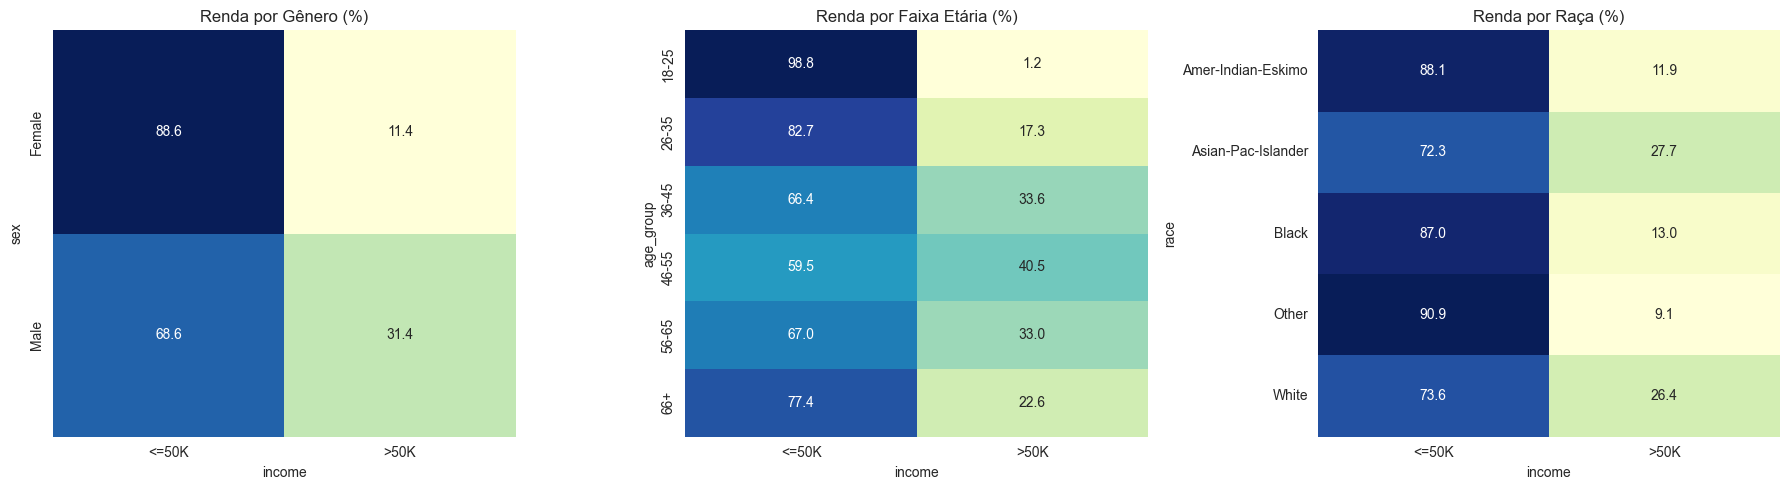

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
print("\n--- Bloco 3: Análise de Distribuição de Classes e Visualização ---")

class_col = 'income'

print("\nDistribuição de Renda por Gênero (%):")
gender_dist = pd.crosstab(df['sex'], df[class_col], normalize='index') * 100
print(gender_dist.round(2))

print("\nDistribuição de Renda por Faixa Etária (%):")
age_dist = pd.crosstab(df['age_group'], df[class_col], normalize='index') * 100
print(age_dist.round(2))

print("\nDistribuição de Renda por Raça (%):")
race_dist = pd.crosstab(df['race'], df[class_col], normalize='index') * 100
print(race_dist.round(2))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(gender_dist, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False)
plt.title('Renda por Gênero (%)')

plt.subplot(1, 3, 2)
sns.heatmap(age_dist, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False)
plt.title('Renda por Faixa Etária (%)')

plt.subplot(1, 3, 3)
sns.heatmap(race_dist, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False)
plt.title('Renda por Raça (%)')

plt.tight_layout()
plt.show() 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
print("\n--- Bloco 4: Variáveis Sensíveis, Desequilíbrios e Correlações Problemáticas ---")

sensitive_vars = ['sex', 'race', 'age', 'native-country']
print(f"\nVariáveis que podem ser consideradas sensíveis (Quasi-identificadores): {sensitive_vars}")
print("A análise de distribuição (Bloco 3) já mostra o impacto dessas variáveis na classe 'income'.")

print("\nAnálise de Desequilíbrio na Variável Alvo ('income'):")
income_counts = df['income'].value_counts(normalize=True) * 100
print(income_counts.round(2))
print(f"O dataset apresenta um desequilíbrio significativo, com {income_counts.iloc[0]:.2f}% da classe majoritária.")

df_corr = df_anon.copy()
df_corr['sex_encoded'] = df['sex'].apply(lambda x: 1 if x == 'Male' else 0)
df_corr['race_encoded'] = df['race'].apply(lambda x: 1 if x == 'White' else 0) 
df_corr['age_encoded'] = df['age'] 

target_corr = df_corr.corr(numeric_only=True)['income_encoded'].sort_values(ascending=False)

print("\nCorrelação (Pearson) com a Variável Alvo ('income_encoded'):")
print(target_corr.head(10))

sex_corr = target_corr.get('sex_encoded', 0)
race_corr = target_corr.get('race_encoded', 0)

print("\nCorrelações Problemáticas (Indícios de Vieses):")
print(f"A variável 'sex_encoded' (gênero) tem uma correlação de {sex_corr:.4f} com a renda.")
print(f"A variável 'race_encoded' (raça - White) tem uma correlação de {race_corr:.4f} com a renda.")
print("Essas correlações, juntamente com a distribuição desigual (Bloco 3), sugerem um potencial **viés de representação** e **viés de alocação** no dataset, onde o modelo pode aprender a discriminar com base em atributos sensíveis.")


--- Bloco 4: Variáveis Sensíveis, Desequilíbrios e Correlações Problemáticas ---

Variáveis que podem ser consideradas sensíveis (Quasi-identificadores): ['sex', 'race', 'age', 'native-country']
A análise de distribuição (Bloco 3) já mostra o impacto dessas variáveis na classe 'income'.

Análise de Desequilíbrio na Variável Alvo ('income'):
income
<=50K    75.11
>50K     24.89
Name: proportion, dtype: float64
O dataset apresenta um desequilíbrio significativo, com 75.11% da classe majoritária.

Correlação (Pearson) com a Variável Alvo ('income_encoded'):
income_encoded                       1.000000
marital-status_Married-civ-spouse    0.445418
education-num                        0.335286
age_encoded                          0.241998
hours-per-week                       0.229480
capital-gain                         0.221196
sex_encoded                          0.216699
sex_Male                             0.216699
occupation_Exec-managerial           0.213442
occupation_Prof-specialt